# Análisis de Señales de Electroencefalografía (EEG) Notebook
---


En este Jupyter Notebook se detalla el procedimiento completo para el procesamiento y análisis de las señales de EEG adquiridas con los dispositivos BITalino y Ultracortex Mark IV. El objetivo es transformar los datos crudos en métricas fisiológicas interpretables, principalmente a través del análisis en el dominio de la frecuencia, para comparar diferentes estados fisiológicos: reposo con ojos abiertos y cerrados, tareas cognitivas y exposición a artefactos.

El análisis se estructura en las siguientes fases:

1.  **Configuración del Entorno y Carga de Datos:** Importación de librerías y carga estructurada de los datos de ambos dispositivos.
2.  **Procesamiento Fundamental y Segmentación:** Filtrado de las señales y segmentación según los protocolos experimentales.
3.  **Análisis de Frecuencia y Estadístico:** Aplicación del método de Welch, espectrogramas y pruebas estadísticas para cuantificar los cambios en las bandas de frecuencia del EEG.
4.  **Análisis Avanzado y Discusión:** Detección de artefactos y aplicación de clustering para la identificación de estados cerebrales.

---
## **Fase 1: Configuración del Entorno y Carga de Datos**

----

### 1.1. Importación de Librerías y Definición de Constantes

Iniciamos importando las librerías de Python necesarias para todo el análisis. Adicionalmente, definimos un diccionario con las bandas de frecuencia estándar del EEG. Esto nos permitirá referenciar estas bandas de forma consistente a lo largo del cuaderno.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch, spectrogram
from scipy.stats import ttest_rel
from sklearn.cluster import KMeans
import warnings

# Configuraciones Generales
# Estilo para los gráficos
sns.set(style="whitegrid")
# Ignorar advertencias para una salida más limpia
warnings.filterwarnings('ignore')

# Constantes del Análisis EEG
# Bandas de frecuencia estándar del EEG en Hz
BANDAS_EEG = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alfa': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 50)
}

print("Librerías importadas y constantes definidas.")

Librerías importadas y constantes definidas.


### 1.2. Funciones para la Carga de Datos

Dado que trabajamos con dos fuentes de datos distintas (BITalino y Ultracortex), cada una con su propio formato de archivo, creamos funciones específicas para cargar cada tipo de señal. Esto asegura que los datos se lean correctamente y se estructuren de manera uniforme para el análisis posterior.

In [2]:
def cargar_senal_bitalino(ruta_archivo, fs=1000):
    """
    Carga una señal desde un archivo '_converted.txt' de BITalino.
    Maneja el encabezado y extrae la señal de la COLUMNA 5.
    """
    try:
        with open(ruta_archivo, 'r') as f:
            for i, linea in enumerate(f):
                if "EndOfHeader" in linea:
                    skiprows = i + 1
                    break
            else:
                skiprows = 0
        
        df = pd.read_csv(ruta_archivo, sep="\t", skiprows=skiprows, header=None)
        
        # Seleccionamos explícitamente la columna 5 por ser el canal usado para EEG (la sexta columna)
        senal = df.iloc[:, 5].values 
        
        tiempo = np.arange(len(senal)) / fs
        return tiempo, senal
    except Exception as e:
        print(f"Error al cargar el archivo BITalino {os.path.basename(ruta_archivo)}: {e}")
        return None, None

def cargar_senal_ultracortex(ruta_archivo, fs=250):
    """
    Carga una señal desde un archivo .txt de OpenBCI (Ultracortex).
    Maneja el encabezado comentado con '%' y extrae los 8 canales EXG.
    """
    try:
        df = pd.read_csv(ruta_archivo, comment='%')
        df.columns = df.columns.str.strip()
        
        canales_eeg_cols = [f'EXG Channel {i}' for i in range(8)]
        canales_eeg = df[canales_eeg_cols].values
        
        tiempo = df['Sample Index'].values / fs
        return tiempo, canales_eeg
    except Exception as e:
        print(f"Error al cargar el archivo Ultracortex {os.path.basename(ruta_archivo)}: {e}")
        return None, None

print("Funciones de carga de datos definidas.")

Funciones de carga de datos definidas.


### 1.3. Carga de los Archivos de Señales

Ahora utilizamos las funciones definidas para cargar todos los archivos de los experimentos en dos diccionarios, uno para cada dispositivo, para mantener los datos organizados.


In [3]:
# Rutas y Nombres de Archivos
RUTA_BASE = "../Señales_adquiridas_en_el_laboratorio/"

# Archivos de BITalino
archivos_bitalino = [
    "EEG_reposo_1_converted.txt", "EEG_reposo_2_converted.txt", "EEG_reposo_3_converted.txt",
    "EEG_resta_100_converted.txt",
    "EEG_parpadeo_1_converted.txt", "EEG_parpadeo_2_converted.txt", "EEG_parpadeo_3_converted.txt",
    "EEG_musica_1_converted.txt", "EEG_musica_2_converted.txt"
]
FS_BITALINO = 1000

# Archivo de Ultracortex
archivo_ultracortex = "OpenBCI-RAW-2025-09-17_12-45-51.txt"
FS_ULTRACORTEX = 250

# Carga de Datos 
datos_bitalino = {}
print("--- Cargando datos de BITalino ---")
for archivo in archivos_bitalino:
    ruta_completa = os.path.join(RUTA_BASE, archivo)
    if os.path.exists(ruta_completa):
        tiempo, senal = cargar_senal_bitalino(ruta_completa, fs=FS_BITALINO)
        if tiempo is not None:
            datos_bitalino[archivo] = {'tiempo': tiempo, 'senal': senal, 'fs': FS_BITALINO}
            print(f"  - Archivo '{archivo}' cargado exitosamente.")
    else:
        print(f"  - Archivo '{archivo}' no encontrado en la ruta.")

datos_ultracortex = {}
print("\n--- Cargando datos de Ultracortex ---")
ruta_completa = os.path.join(RUTA_BASE, archivo_ultracortex)
if os.path.exists(ruta_completa):
    tiempo, senales = cargar_senal_ultracortex(ruta_completa, fs=FS_ULTRACORTEX)
    if tiempo is not None:
        datos_ultracortex = {'tiempo': tiempo, 'senales': senales, 'fs': FS_ULTRACORTEX}
        print(f"  - Archivo '{archivo_ultracortex}' cargado exitosamente.")
else:
    print(f"  - Archivo '{archivo_ultracortex}' no encontrado en la ruta.")

--- Cargando datos de BITalino ---
  - Archivo 'EEG_reposo_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_reposo_2_converted.txt' cargado exitosamente.
  - Archivo 'EEG_reposo_3_converted.txt' cargado exitosamente.
  - Archivo 'EEG_resta_100_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_2_converted.txt' cargado exitosamente.
  - Archivo 'EEG_parpadeo_3_converted.txt' cargado exitosamente.
  - Archivo 'EEG_musica_1_converted.txt' cargado exitosamente.
  - Archivo 'EEG_musica_2_converted.txt' cargado exitosamente.

--- Cargando datos de Ultracortex ---
  - Archivo 'OpenBCI-RAW-2025-09-17_12-45-51.txt' cargado exitosamente.


---
## **Fase 2: Procesamiento Fundamental y Segmentación de Señales**

----

### 2.1. Filtrado de las Señales EEG

El filtrado es un paso imprescindible en el análisis de EEG para aislar la actividad neuronal de los artefactos externos. Las señales de EEG son de muy baja amplitud (microvoltios), lo que las hace altamente susceptibles al ruido. Aplicamos dos tipos de filtros:

1.  **Filtro Pasa-Banda:** Se utiliza un filtro Butterworth de orden 5 entre 1 Hz y 50 Hz. La frecuencia de corte baja (1 Hz) elimina la deriva de la línea de base (o también llamada componente DC), mientras que la frecuencia de corte alta (50 Hz) atenúa el ruido muscular (EMG) de alta frecuencia sin afectar significativamente las bandas de interés [1].
2.  **Filtro Notch:** Se aplica un filtro específico para eliminar la interferencia de la red eléctrica, que en Perú es de 60 Hz. Este tipo de ruido es muy común y puede enmascarar la actividad cerebral si no se elimina adecuadamente, esto para cualquier señal del mismo tipo que pueda haber sido adquirida, sin embargo el grupo en este caso, desconectó la toma de la laptop para tratar de mitigar este efecto [1].

In [4]:
def aplicar_filtros_eeg(senal, fs, low_cut=1, high_cut=50, notch_freq=60):
    # Aplica un filtro pasa-banda y un filtro de muesca (notch) a una señal de EEG.
    # Filtro Pasa-Banda 
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(5, [low, high], btype='band')
    senal_filtrada = filtfilt(b, a, senal)
    
    # Filtro de Muesca (Notch)
    q_factor = 30.0
    b_notch, a_notch = butter(2, [notch_freq-1, notch_freq+1], btype='bandstop', fs=fs)
    senal_final = filtfilt(b_notch, a_notch, senal_filtrada)
    
    return senal_final

# Aplicar filtrado a los datos de BITalino
print("--- Filtrando datos de BITalino ---")
for archivo, data in datos_bitalino.items():
    if 'senal' in data and len(data['senal']) > 0:
        data['senal_filtrada'] = aplicar_filtros_eeg(data['senal'], data['fs'])
        print(f"  - Señal '{archivo}' filtrada.")
    else:
        data['senal_filtrada'] = np.array([]) # Asegurarse de que exista la clave
        print(f"  - Señal '{archivo}' está vacía, no se puede filtrar.")

# Aplicar filtrado a los datos de Ultracortex (canal por canal)
print("\n--- Filtrando datos de Ultracortex ---")
if datos_ultracortex and 'senales' in datos_ultracortex:
    senales_filtradas_uc = []
    for i in range(datos_ultracortex['senales'].shape[1]):
        canal_filtrado = aplicar_filtros_eeg(datos_ultracortex['senales'][:, i], datos_ultracortex['fs'])
        senales_filtradas_uc.append(canal_filtrado)
        print(f"  - Canal {i} filtrado.")
    datos_ultracortex['senales_filtradas'] = np.array(senales_filtradas_uc).T
else:
    print("No hay datos de Ultracortex para filtrar.")

print("\nFiltrado completado.")

--- Filtrando datos de BITalino ---
  - Señal 'EEG_reposo_1_converted.txt' filtrada.
  - Señal 'EEG_reposo_2_converted.txt' filtrada.
  - Señal 'EEG_reposo_3_converted.txt' filtrada.
  - Señal 'EEG_resta_100_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_1_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_2_converted.txt' filtrada.
  - Señal 'EEG_parpadeo_3_converted.txt' filtrada.
  - Señal 'EEG_musica_1_converted.txt' filtrada.
  - Señal 'EEG_musica_2_converted.txt' filtrada.

--- Filtrando datos de Ultracortex ---
  - Canal 0 filtrado.
  - Canal 1 filtrado.
  - Canal 2 filtrado.
  - Canal 3 filtrado.
  - Canal 4 filtrado.
  - Canal 5 filtrado.
  - Canal 6 filtrado.
  - Canal 7 filtrado.

Filtrado completado.


### 2.1.1. Verificación Visual Post-Filtrado

Para asegurarnos de que los datos se han cargado y filtrado correctamente, graficamos los primeros 15 segundos de cada señal filtrada.

--- Visualizando señales filtradas de BITalino ---


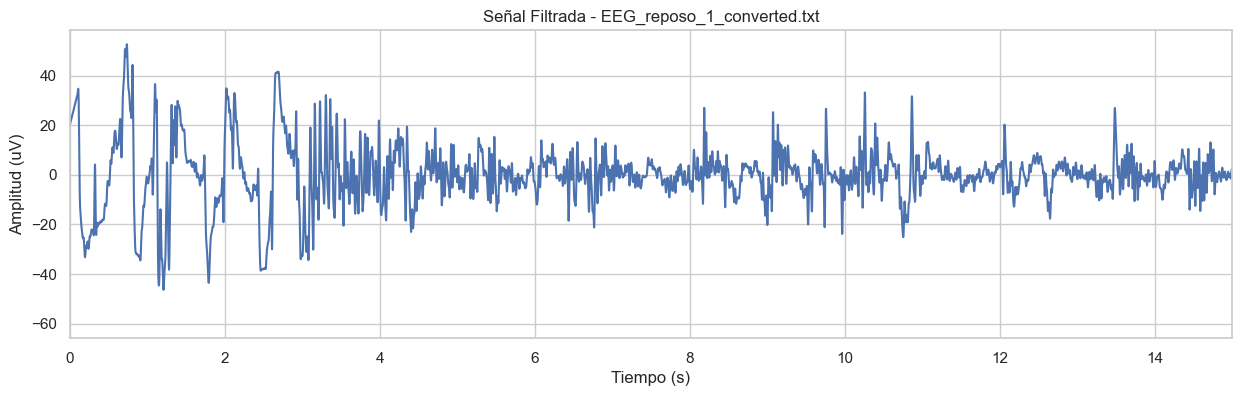

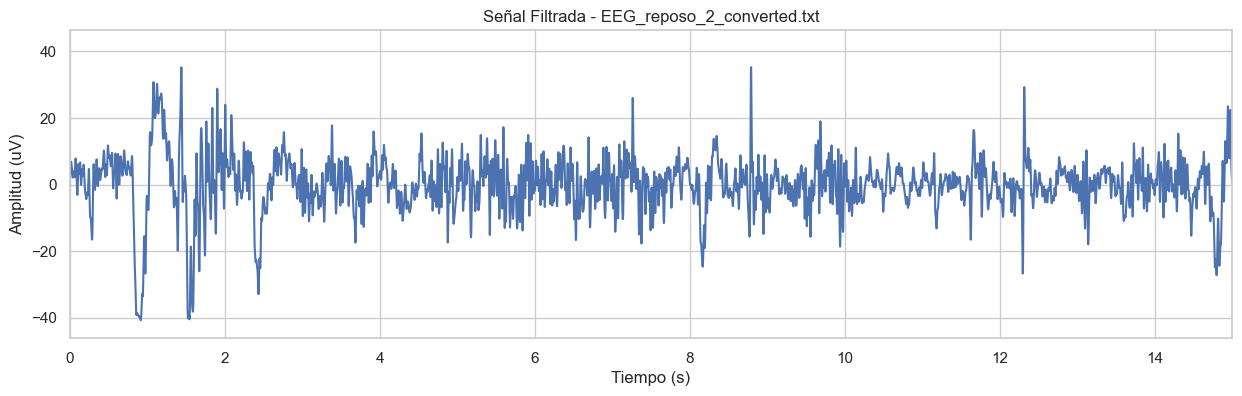

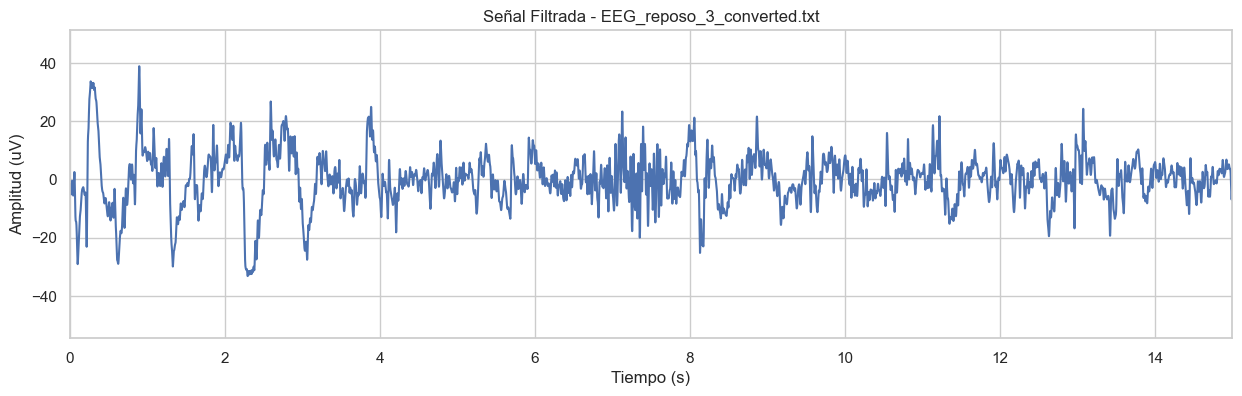

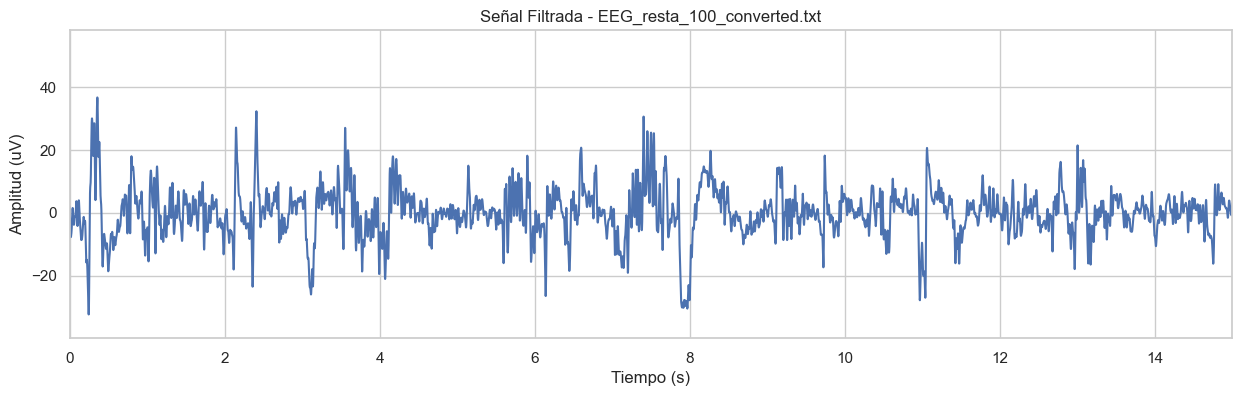

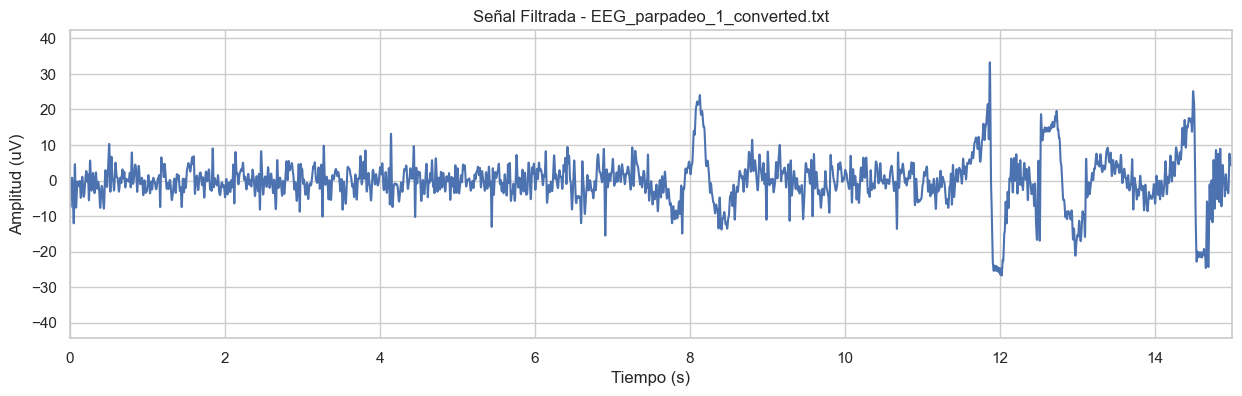

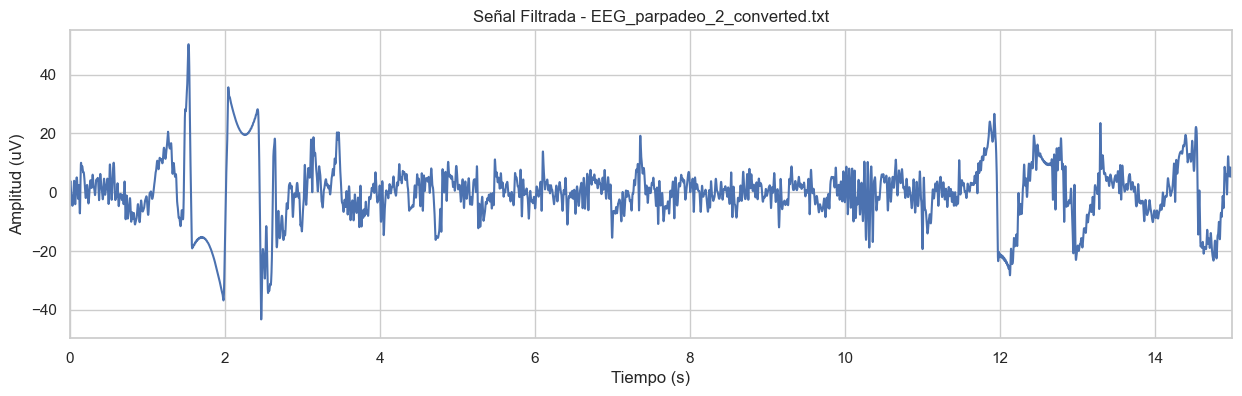

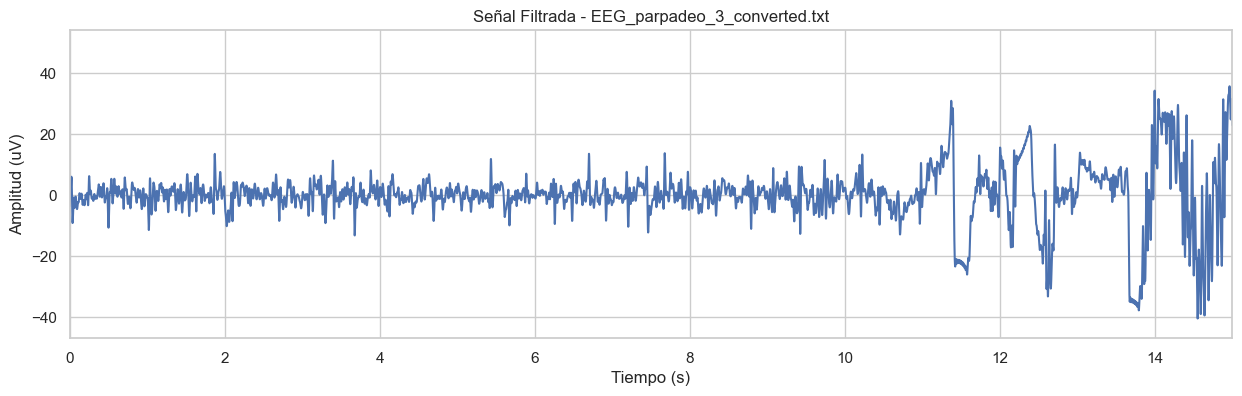

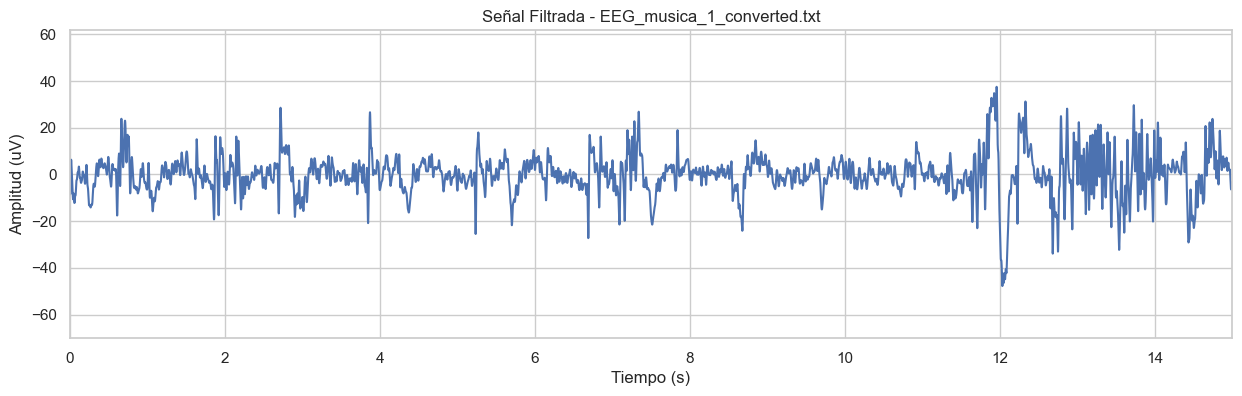

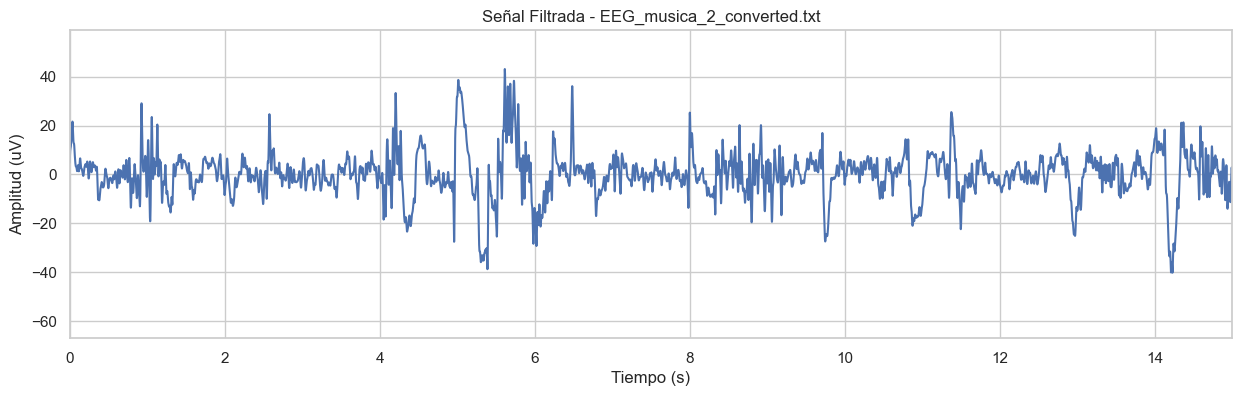


--- Visualizando señal filtrada de Ultracortex (Canal 0) ---


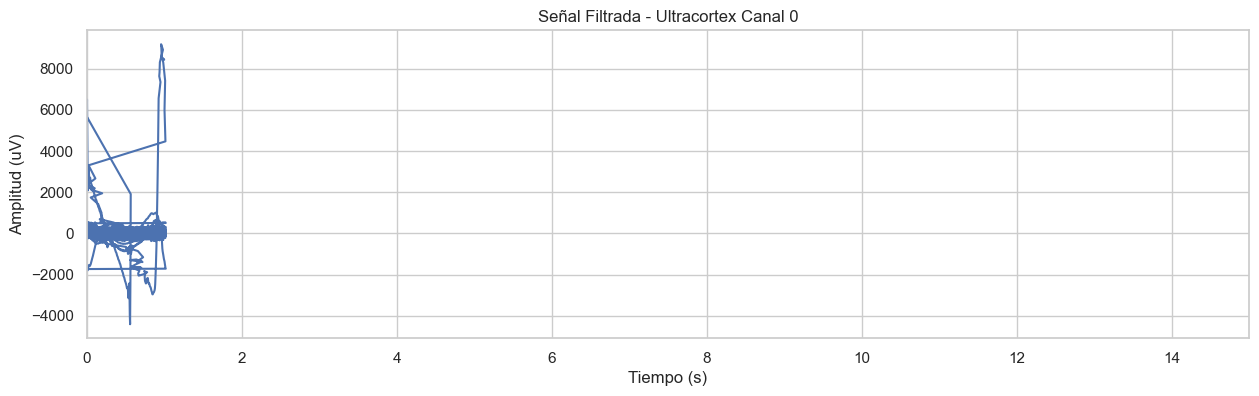

In [5]:
print("--- Visualizando señales filtradas de BITalino ---")
for archivo, data in datos_bitalino.items():
    plt.figure(figsize=(15, 4))
    plt.plot(data['tiempo'], data['senal_filtrada'])
    plt.title(f'Señal Filtrada - {archivo}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.xlim(0, 15) # Mostrar los primeros 15 segundos
    plt.grid(True)
    plt.show()

print("\n--- Visualizando señal filtrada de Ultracortex (Canal 0) ---")
if datos_ultracortex:
    plt.figure(figsize=(15, 4))
    plt.plot(datos_ultracortex['tiempo'], datos_ultracortex['senales_filtradas'][:, 0]) # Graficamos solo el primer canal como ejemplo
    plt.title('Señal Filtrada - Ultracortex Canal 0')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (uV)')
    plt.xlim(0, 15)
    plt.grid(True)
    plt.show()

### 2.2. Segmentación por Protocolo Experimental

Para realizar comparaciones válidas entre las diferentes tareas, es fundamental aislar con precisión los periodos de tiempo que corresponden a cada estado fisiológico. Basándonos en los protocolos de adquisición, definimos las ventanas de tiempo para cada evento y extraemos los segmentos correspondientes de las señales ya filtradas.

In [6]:
def segmentar_senal(tiempo, senal, inicio_s, fin_s):
    #    Extrae un segmento de una señal basado en tiempos de inicio y fin en segundos.
    idx_segmento = np.where((tiempo >= inicio_s) & (tiempo < fin_s))[0]
    # Devuelve una rebanada de la señal original para evitar errores con arrays vacíos
    return senal[idx_segmento] if len(idx_segmento) > 0 else np.array([])

# Protocolo de BITalino ---
segmentos_bitalino_reposo = {}
for i in range(1, 4):
    archivo = f'EEG_reposo_{i}_converted.txt'
    if archivo in datos_bitalino:
        t = datos_bitalino[archivo]['tiempo']
        s = datos_bitalino[archivo]['senal_filtrada']
        segmentos_bitalino_reposo[f'reposo_{i}'] = {
            'ojos_cerrados_inicio': segmentar_senal(t, s, 0, 30),
            'ojos_abiertos': segmentar_senal(t, s, 30, 150),
            'ojos_cerrados_final': segmentar_senal(t, s, 150, 180)
        }

segmentos_bitalino_resta = {}
archivo = 'EEG_resta_100_converted.txt'
if archivo in datos_bitalino:
    t = datos_bitalino[archivo]['tiempo']
    s = datos_bitalino[archivo]['senal_filtrada']
    segmentos_bitalino_resta = {
        'linea_base': segmentar_senal(t, s, 0, 10),
        'calculo_mental': segmentar_senal(t, s, 10, t[-1]) # hasta el final
    }

segmentos_bitalino_parpadeo = {}
for i in range(1, 4):
    archivo = f'EEG_parpadeo_{i}_converted.txt'
    if archivo in datos_bitalino:
        t = datos_bitalino[archivo]['tiempo']
        s = datos_bitalino[archivo]['senal_filtrada']
        segmentos_bitalino_parpadeo[f'parpadeo_{i}'] = {
            'linea_base': segmentar_senal(t, s, 0, 10),
            'parpadeos': segmentar_senal(t, s, 10, t[-1])
        }

# Protocolo de Ultracortex (con verificación de seguridad) ---
segmentos_ultracortex = {}
if datos_ultracortex:  # Solo ejecuta si el diccionario no está vacío
    t_uc = datos_ultracortex['tiempo']
    s_uc = datos_ultracortex['senales_filtradas']
    segmentos_ultracortex = {
        'ojos_abiertos': segmentar_senal(t_uc, s_uc, 0, 60),
        'ojos_cerrados': segmentar_senal(t_uc, s_uc, 60, 120),
        'calculo_mental': segmentar_senal(t_uc, s_uc, 120, 240),
        'artefactos': segmentar_senal(t_uc, s_uc, 240, 360),
        'musica': segmentar_senal(t_uc, s_uc, 360, 720)
    }

print("Segmentación de todas las señales completada según los protocolos.")

Segmentación de todas las señales completada según los protocolos.


### 3.1. Análisis de Potencia Espectral (PSD): Ritmos Alfa en Reposo

Uno de los fenómenos más conocidos del EEG es la modulación del ritmo alfa. La potencia en la banda alfa (8-13 Hz) tiende a aumentar significativamente cuando un sujeto está en un estado de relajación con los ojos cerrados, y disminuye al abrirlos debido al procesamiento de la información visual [2].

Para cuantificar este efecto, utilizamos el **método de Welch**. Esta técnica calcula el Espectro de Densidad de Potencia (PSD) promediando periodogramas de segmentos cortos y superpuestos de la señal, lo que resulta en una estimación de la potencia más suave y fiable en comparación con un simple cálculo de la FFT sobre toda la señal [3]. Compararemos la potencia alfa promedio de los tres ensayos de reposo entre los segmentos de "ojos cerrados" y "ojos abiertos".

Potencia Alfa Promedio (Ojos Cerrados): 4.9706 uV^2
Potencia Alfa Promedio (Ojos Abiertos): 2.8007 uV^2


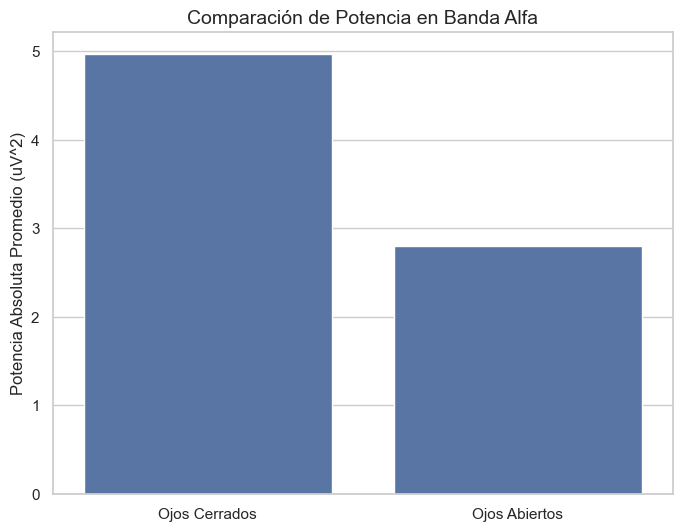

In [7]:
def calcular_potencia_banda(senal, fs, banda, nperseg=2048):
    # Calcula la potencia absoluta promedio en una banda de frecuencia específica utilizando el método de Welch.
    f, psd = welch(senal, fs, nperseg=nperseg)
    freq_res = f[1] - f[0]
    
    # Encontrar los índices de frecuencia que corresponden a la banda
    idx_banda = np.where((f >= BANDAS_EEG[banda][0]) & (f <= BANDAS_EEG[banda][1]))[0]
    
    # Calcular la potencia sumando la densidad de potencia y multiplicando por la resolución
    potencia = np.sum(psd[idx_banda]) * freq_res
    return potencia

# Comparar potencia alfa en ojos cerrados vs. abiertos 
potencia_alfa_cerrados = []
potencia_alfa_abiertos = []

# Usamos los datos de BITalino por su mayor frecuencia de muestreo para este análisis
for i in range(1, 4):
    nombre_ensayo = f'reposo_{i}'
    if nombre_ensayo in segmentos_bitalino_reposo:
        # Usamos el primer segmento de ojos cerrados para la comparación
        segmento_cerrados = segmentos_bitalino_reposo[nombre_ensayo]['ojos_cerrados_inicio']
        segmento_abiertos = segmentos_bitalino_reposo[nombre_ensayo]['ojos_abiertos']
        
        # Calcular potencia
        pot_cerrados = calcular_potencia_banda(segmento_cerrados, FS_BITALINO, 'alfa')
        pot_abiertos = calcular_potencia_banda(segmento_abiertos, FS_BITALINO, 'alfa')
        
        potencia_alfa_cerrados.append(pot_cerrados)
        potencia_alfa_abiertos.append(pot_abiertos)

# Visualización de Resultados
if potencia_alfa_cerrados:
    media_cerrados = np.mean(potencia_alfa_cerrados)
    media_abiertos = np.mean(potencia_alfa_abiertos)

    print(f"Potencia Alfa Promedio (Ojos Cerrados): {media_cerrados:.4f} uV^2")
    print(f"Potencia Alfa Promedio (Ojos Abiertos): {media_abiertos:.4f} uV^2")

    # Gráfico de barras para comparar
    plt.figure(figsize=(8, 6))
    sns.barplot(x=['Ojos Cerrados', 'Ojos Abiertos'], y=[media_cerrados, media_abiertos])
    plt.title('Comparación de Potencia en Banda Alfa', fontsize=14)
    plt.ylabel('Potencia Absoluta Promedio (uV^2)')
    plt.show()

### 3.2. Análisis de Potencia Espectral (PSD): Ritmos Beta en Tarea Cognitiva

La actividad en la banda beta (13-30 Hz) está asociada con el estado de alerta, la concentración y el procesamiento cognitivo activo. Se hipotetiza que la potencia en esta banda aumentará durante una tarea mentalmente exigente, como la resta seriada, en comparación con un estado de reposo previo [4].

Para verificar esto, comparamos la potencia beta del segmento de "línea de base" con la del segmento de "cálculo mental". Dado que estas dos mediciones provienen del mismo ensayo (son pareadas), utilizamos una **prueba t de Student para muestras pareadas**. Esta prueba estadística es la adecuada para determinar si el cambio observado es estadísticamente significativo.

Potencia Beta (Línea Base): 12.3698 uV^2
Potencia Beta (Cálculo Mental): 5.4666 uV^2

--- Resultados de la Prueba t Pareada ---
Estadístico t: 0.91
Valor p: 0.4284
Conclusión: No hay evidencia de un incremento estadísticamente significativo en la potencia beta.


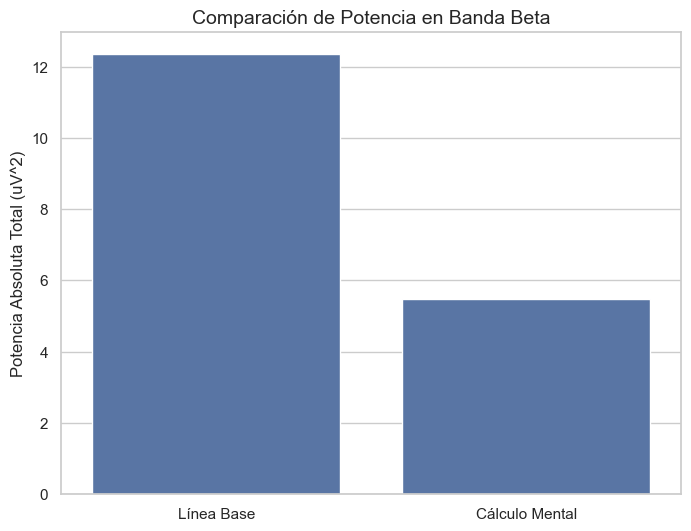

In [8]:
# Comparar potencia beta en reposo vs. cálculo mental
if 'linea_base' in segmentos_bitalino_resta:
    segmento_base = segmentos_bitalino_resta['linea_base']
    segmento_calculo = segmentos_bitalino_resta['calculo_mental']

    # Calcular la potencia beta para cada segmento
    pot_beta_base = calcular_potencia_banda(segmento_base, FS_BITALINO, 'beta')
    pot_beta_calculo = calcular_potencia_banda(segmento_calculo, FS_BITALINO, 'beta')

    print(f"Potencia Beta (Línea Base): {pot_beta_base:.4f} uV^2")
    print(f"Potencia Beta (Cálculo Mental): {pot_beta_calculo:.4f} uV^2")
    
    # Prueba t de Student Pareada
    # Para la prueba, necesitamos dividir los segmentos en ventanas más pequeñas
    # para tener múltiples muestras para la estadística.
    longitud_ventana = 2 * FS_BITALINO # Ventanas de 2 segundos
    
    ventanas_base = [segmento_base[i:i+longitud_ventana] for i in range(0, len(segmento_base) - longitud_ventana, longitud_ventana)]
    ventanas_calculo = [segmento_calculo[i:i+longitud_ventana] for i in range(0, len(segmento_calculo) - longitud_ventana, longitud_ventana)]
    
    # Nos aseguramos de tener el mismo número de ventanas para comparar
    n_ventanas = min(len(ventanas_base), len(ventanas_calculo))
    
    if n_ventanas > 1:
        potencias_beta_base = [calcular_potencia_banda(v, FS_BITALINO, 'beta') for v in ventanas_base[:n_ventanas]]
        potencias_beta_calculo = [calcular_potencia_banda(v, FS_BITALINO, 'beta') for v in ventanas_calculo[:n_ventanas]]
        
        t_stat, p_value = ttest_rel(potencias_beta_calculo, potencias_beta_base)

        print("\n--- Resultados de la Prueba t Pareada ---")
        print(f"Estadístico t: {t_stat:.2f}")
        print(f"Valor p: {p_value:.4f}")

        if p_value < 0.05:
            print("Conclusión: El incremento en la potencia beta durante el cálculo es estadísticamente significativo.")
        else:
            print("Conclusión: No hay evidencia de un incremento estadísticamente significativo en la potencia beta.")

    # Gráfico de barras para comparar
    plt.figure(figsize=(8, 6))
    sns.barplot(x=['Línea Base', 'Cálculo Mental'], y=[pot_beta_base, pot_beta_calculo])
    plt.title('Comparación de Potencia en Banda Beta', fontsize=14)
    plt.ylabel('Potencia Absoluta Total (uV^2)')
    plt.show()

else:
    print("No se encontraron los datos del experimento de resta para analizar.")